# Data Preprocessing II
Feature Selection, Hyperparameter Optimization

# Feature Selection이란?
주어진 feature 중에서 필요한 feature만을 선택하는 방법

## Feature Selection의 장점
- 차원의 저주 방지
- 성능 향상
- 학습 시간 및 계산 비용 감소
- 이해 및 해석 용이
- 모델의 강건성

### Filter Method란?
feature들의 통계적 속성을 기반으로 feature를 선택하는 방법
- Information Gain (정보 이득)
- Chi-square Test (카이제곱 검정)
- Correlation Coefficient (상관 계수)
- Variance Threshold (분산 임계값)

### Wrapper Method란?
feature의 부분 집합을 사용하여 모델의 성능을 평가하고 최적의 feature 집합을 선택하는 방법
- Forward Selection (전진 선택법)
- Backward Selection (후진 제거법)
- Stepwise Selection (단계별 선택법)

### Embedded Method란?
모델 자체에서 feature를 선택하는 방법으로, L1 정규화 기법 등을 사용하여 feature를   
선택하거나 가중치를 줄이는 방식
- Lasso: L1-norm을 통해 제약을 주는 방법
- Ridge: L2-norm을 통해 제약을 주는 방법
- Elastic Net: 위 둘을 선형결합한 방법
- Select From Model: 트리 기반 알고리즘에서 feature를 뽑아오는 방법
  (ex. RandomForest, LightGBM 등)
  
### eXplainable AI란?
모델 및 feature에 대한 이해를 바탕으로 feature selection을 진행
- SHAP (SHapley Additive exPlanations)
  각 예측에 대해 각 feature의 ‘기여도’를 측정
  
기여도와 중요도의 차이점  
- 중요도: 각 피처가 모델의 예측 성능에 얼마나 기여하는가  
  (개별 관찰치에서 각 피처가 얼마나 기여하는지 알수 X)  
- 기여도: 개별 관찰치에서의 각 피처의 기여도를 확인 가능  
  (개별 관찰치에서 각 변수의 중요도와 방향성 제공)

## Hyperparameter Optimization
가장 좋은 성능을 내는 하이퍼파라미터 조합 찾는 과정

### Grid Search란?
가능한 모든 하이퍼파라미터 조합을 시도해보고 가장 좋은 결과를 내는 조합을 선택  
직관적이며 하이퍼파라미터 탐색 공간이 좁은 경우 효과적  
지정한 하이퍼파라미터 후보군의 개수만큼 비례하여 탐색 시간이 늘어남  

### Random Search란?
지정된 분포에서 무작위로 선택한 하이퍼파라미터 값을 사용하여 모델을 학습하고 평가  
Grid Search보다 최적 하이퍼파라미터를 먼저 찾을 수 있음 (시간 대비 성능 좋음) 
하이퍼파라미터 탐색 공간이 클 경우 사용하면 좋음  
최적값 근처를 정밀하게 탐색하지 못할 수 있음  

### Bayesian Optimization이란?
미지의 목적함수를 최대화 or 최소화하는 최적해를 찾는 기법  
- Surrogate Model: 목적 함수의 근사 모델 (현재까지 수집된 관측치 데이터를 기반으로 구축)
- Acquisition Function: Surrogate Model을 바탕으로 다음 입력값 후보를 추천해주는 함수


### 보스턴 집값예측 Data
##### 주택 가격을 예측하는 회귀 분석 문제

#### 독립변수 
##### 영향을 주는 변수, 원인

- CRIM: 범죄율

- INDUS: 비소매상업지역 면적 비율

- NOX: 일산화질소 농도

- RM: 주택당 방 수

- LSTAT: 인구 중 하위 계층 비율

- B: 인구 중 흑인 비율

- PTRATIO: 학생/교사 비율

- ZN: 25,000 평방피트를 초과 거주지역 비율

- CHAS: 찰스강의 경계에 위치한 경우는 1, 아니면 0

- AGE: 1940년 이전에 건축된 주택의 비율

- RAD: 방사형 고속도로까지의 거리

- DIS: 직업센터의 거리

- TAX: 재산세율

<br>

#### 종속변수 
##### 영향을 받는 변수, 결과

- MEDV : 보스턴 506개 타운의 1978년 주택 가격 중앙값 (단위 1,000 달러)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import klib
from sklearn.model_selection import train_test_split

#ignore warningss
import warnings
warnings.filterwarnings('ignore')

In [2]:
boston_df = pd.read_csv('data/boston.csv')

In [3]:
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [4]:
boston_target = boston_df[['MEDV']]

In [5]:
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### 기본 성능 - 회귀

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = boston_df.drop('MEDV', axis=1) 
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2) 

R^2 Score: 0.8772372315367486


# 01. Feature Selection
---

### 1) Filter Method - 상관관계(corr)를 활용한 Feature Selection

- faeture 간의 correlation coeffiecient를 활용해 중요한 피쳐, 그렇지 않은 feature를 골라낸다.
- 상관계수의 범위는 -1 < x < 1 사이다.
- 상관 계수의 절대값이 클수록 두 변수 간의 선형적 관계가 강하다고 할 수 있다.
- 음수일 경우 음의 상관관계, 양수일 경우 양의 상관관계를 갖는다.
- 상관계수가 -0.1에서 0.1 사이라면 거의 관계가 없다고 볼 수 있다.

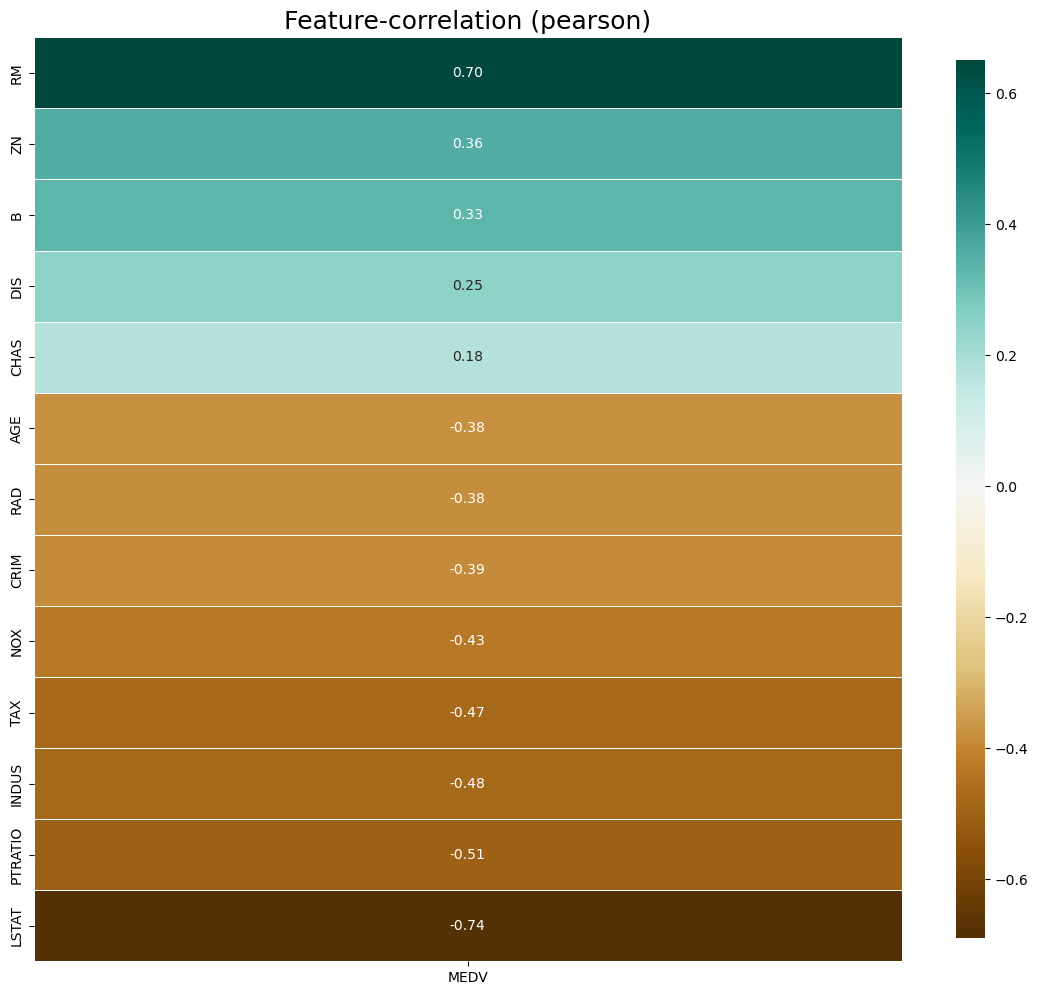

In [8]:
klib.corr_plot(data = boston_df.iloc[:, :-1], # 독립변수 (target 제외)
               target = boston_df.iloc[:, -1] ,
               figsize = (14, 12))

plt.show() 

종속변수와 각 feature 간 상관 관계를 분석했을 때, DIS, CHAS 변수는 y값인 MEDV와의 상관성이 미미해 보인다.
  
<font color = blue> --> DIS, CHAS 변수는 종속변수와 상관성이 떨어지기 때문에 제거 고려

In [9]:
X = boston_df.drop(['DIS', 'CHAS', 'MEDV'], axis=1) 
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R^2 Score:", r2) # 성능 상승 -> 타당

R^2 Score: 0.8548776813592807


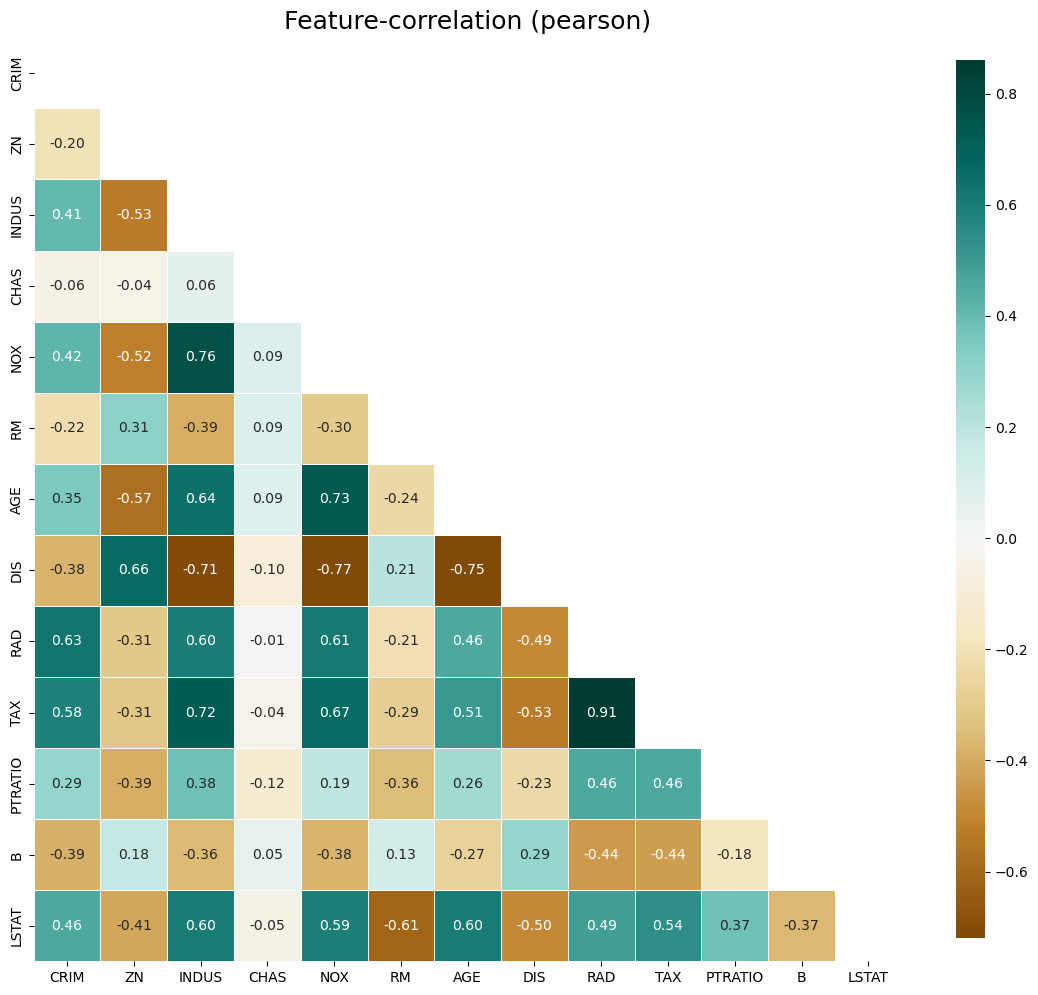

In [10]:
klib.corr_plot(data = boston_df.iloc[:, :-1] ,figsize = (14, 12))
plt.show()

독립변수 간 상관성을 확인했을 때, TAX 와 RAD 는 0.91로 상관성이 강하게 나타난다.

<font color = blue> --> 두 독립변수의 너무 높은 상관관계가 다중공선성, 과적합 등의 문제로 성능을 저하시킬 수 있으므로 둘 중 한 Feature를 제거 고려

In [11]:
X = boston_df.drop(['RAD', 'MEDV'], axis=1) 
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R^2 Score:", r2) # 성능 상승 -> RAD 만 삭제

R^2 Score: 0.8774396178962883


### 2) Wrapper Method - RFE를 활용한 feature selection
- 전체 feature을 포함하여 모델을 학습하고 이후 feature을 하나씩 제거하면서 가장 성능이 놓은 feature subset을 결정하는 방법

In [12]:
from sklearn.feature_selection import RFE

X = boston_df.drop('MEDV', axis=1) 
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(random_state=42) 

# RandomForestRegressor를 사용하여 RFE(Recursive Feature Elimination) 실행
selector = RFE(model, n_features_to_select=6, step=1)  # 원하는 최종 피 수 지정 
selector = selector.fit(X, y)

# 선택된 피처 확인
selected_columns = X_train.columns[selector.support_] #selector.support_: True/False 배열을 확인하고, 선택된 특징들만 추출
print("Selected features:", selected_columns)

# 선택된 피처만을 사용하여 데이터 다시 구성
X = boston_df[selected_columns]
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2)

Selected features: Index(['CRIM', 'NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT'], dtype='object')
R^2 Score: 0.8693971325179068


### 3) Embedded Method - Lasso를 활용한 feature selection

In [13]:
from sklearn.linear_model import Lasso

X = boston_df.drop('MEDV', axis=1)
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 라쏘 회귀 모델을 사용한 피처 선택
lasso = Lasso(alpha=0.4)  # alpha 값은 라쏘 모델의 정규화 강도를 조절
lasso.fit(X_train, y_train)

# 선택된 피처 확인 (계수가 0이 아닌 피처들)
selected_features = [feature for feature, coef in zip(X.columns, lasso.coef_) if coef != 0]

# 선택된 피처를 사용하여 데이터 프레임 재구성
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# 선택된 피처로 RandomForestRegressor 모델 훈련
model = RandomForestRegressor(random_state=42)
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print("Selected features:", selected_features)
print("R^2 Score:", r2)

Selected features: ['CRIM', 'ZN', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
R^2 Score: 0.8612635371886853


### 4) 모델 기반 Feature Selection

In [14]:
from sklearn.feature_selection import SelectFromModel

X = boston_df.drop(['RAD', 'MEDV'], axis=1) 
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 피처 선택을 위해 RandomForestRegressor 모델 사용
selector = SelectFromModel(RandomForestRegressor(random_state=0), threshold=None)
X_train_selected = selector.fit_transform(X_train, y_train)

# 선택된 피처로 테스트 데이터 변형
X_test_selected = selector.transform(X_test)

# 선택된 피처 출력
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)

# 선택된 피처로 RandomForestRegressor 모델 훈련
model = RandomForestRegressor(random_state=42)
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2)

Selected features: Index(['RM', 'LSTAT'], dtype='object')
R^2 Score: 0.7218798100594941


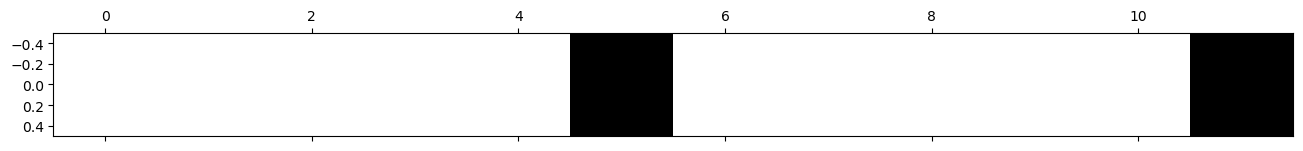

In [15]:
mask = selector.get_support() # 중요도가 높다고 판단한 feature는 True로 반환
plt.matshow(mask.reshape(1,-1), cmap="gray_r")
plt.show()

검은색으로 표시된 부분이 Random Forest Regressor 모델이 중요하다고 여기는 컬럼이다.  
<font color = blue> --> 5번째(RM), 12번째(LSTAT) 컬럼이 중요하구나~ 빼지 말자

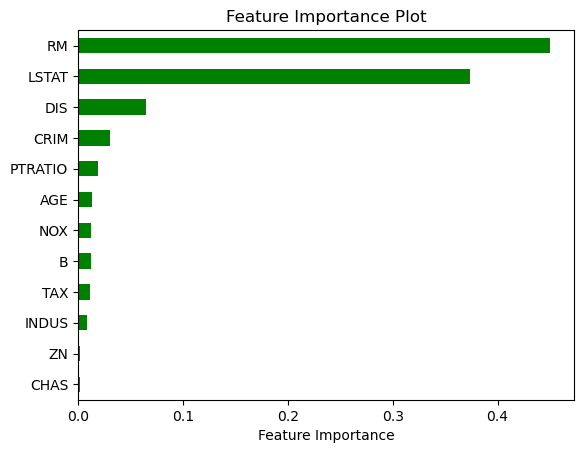

In [16]:
# tree model 기반의 feature importance
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)  # 정확히 선택된 피처 데이터로 학습
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)

# 피처 중요도 시각화
feature_importances.sort_values(ascending=True).plot(kind='barh', color='green')
plt.xlabel('Feature Importance')
plt.title('Feature Importance Plot')
plt.show()

피쳐 중요도를 살펴봤을 때, ZN, CHAS, RAD는 중요도가 낮다고 판단할 수 있다.  
<font color = blue> --> 낮은 중요도와 낮은 상관성 CHAS, 낮은 중요도와 너무 높은 상관성 RAD, 가장 낮은 중요도 ZN 제거 고려

In [39]:
X = boston_df.drop(['CHAS', 'RAD', 'ZN', 'MEDV'], axis=1) 
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R^2 Score:", r2)

R^2 Score: 0.875523360909507


# Feature Selection 결과
-------
### 기본 성능 -> 0.87723   
### Filter Method  
- DIS, CHAS 제거 -> 0.85487  
- RAD 제거 -> 0.87743  
### Wrapper Method  
- CRIM, NOX, RM, DIS, PTRATIO, LSTAT -> 0.86939
### Embedded Method
- CRIM, ZN, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT ->  0.8612
### 모델 기반 Feature Selection
- CHAS, RAD, ZN 제거 -> 0.875523

# 02. Hyperparameter Optimization
---

In [40]:
from sklearn.datasets import load_wine

wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_target = pd.DataFrame(wine.target, columns=["WINE"])
wine_df = pd.concat([wine_df, wine_target], axis = 1)

In [41]:
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,WINE
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(wine_df.iloc[:, :-1], wine_df.iloc[:, -1], test_size=0.2, random_state=1004)

### 단일 모델 - 기본 성능

In [43]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train,y_train)

print(model_tree.score(X_test,y_test)) 

0.8888888888888888


### 1) Grid Search
- 사전에 정의된 하이퍼파라미터의 그리드를 "체계적으로" 탐색하여 모델의 최적의 파라미터를 찾는 방법
- 모든 조합을 탐색할 수 있어서 최적의 파라미터를 놓치지 않지만, 계산 비용이 커서 시간이 많이 소요된다.

In [44]:
from sklearn.model_selection import GridSearchCV

model_dt = DecisionTreeClassifier(random_state=42)

param_grid = {'criterion' : ['gini','entropy'],      # 불순도를 계산하는 척도
              'max_depth': [4,5,6,8,10],             # 깊이, 몇층까지 갈 것인지를 선택
              'min_samples_leaf' : [3,5,10,50,100]}  # 한 노드에 포함되는 샘플의 개수

# 모든 경우의 수 탐색 : 2 * 5 * 5 = 50 번 반복
                 
gcv = GridSearchCV(model_dt,                # 모델
                   param_grid = param_grid, # 탐색할 파라미터들을 딕셔너리 형태로
                   cv = 3,                  # 교차 검증 폴드 수
                   scoring = 'accuracy',    # 성능 평가 지표 - 정확도
                   n_jobs = -1)             # 컴퓨터의 모든 코어 사용

gcv.fit(X_train, y_train)

print('final params', gcv.best_params_)   # 최적의 파라미터 값 출력
print('best score', gcv.best_score_)      # 최고의 점수
print(gcv.score(X_test, y_test))          # 튜닝 전보다 높은 점수

final params {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 3}
best score 0.9086879432624114
0.9444444444444444


### 2) Random Search
- 사전에 정의된 하이퍼파라미터의 그리드를 "랜덤으로" 탐색하여 모델의 최적의 파라미터를 찾는 방법
- 탐색 공간이 클 경우 그리드 탐색보다 더 효율적이지만, 최적의 파라미터를 찾지 못할 가능성이 있다.

In [1]:
from sklearn.model_selection import RandomizedSearchCV

model_dt = DecisionTreeClassifier(random_state=42)

param_grid = {'criterion' : ['gini','entropy'], 
              'max_depth': [4,5,6,8,10],  
              'min_samples_leaf' : range(3, 30, 3)}  

rcv = RandomizedSearchCV(model_dt, 
                         param_distributions = param_grid, 
                         scoring = 'accuracy',
                         n_iter = 8) # 8번 반복

rcv.fit(X_train, y_train)

print('final params', rcv.best_params_)   # 최적의 파라미터 값 출력
print('best score', rcv.best_score_)      # 최고의 점수
print(rcv.score(X_test, y_test))          # 튜닝 전보다 높은 점수

NameError: name 'DecisionTreeClassifier' is not defined

In [46]:
print('기존모델 성능 : ', model_tree.score(X_test,y_test))
print('Grid Search 이용해 튜닝한 모델 성능 : ', gcv.score(X_test, y_test))
print('Random Search 이용해 튜닝한 모델 성능 : ', rcv.score(X_test, y_test))

기존모델 성능 :  0.8888888888888888
Grid Search 이용해 튜닝한 모델 성능 :  0.9444444444444444
Random Search 이용해 튜닝한 모델 성능 :  0.9166666666666666


### 3) Bayesian Optimization
- 목적 함수(탐색대상함수)와 하이퍼파라미터 쌍(pair)을 대상으로 Surrogate Model을 구축
- 순차적으로 하이퍼파라미터를 업데이트해가면서 평가를 통해 최적의 하이퍼파라미터 조합을 탐색

In [47]:
! pip install bayesian-optimization

  Obtaining dependency information for bayesian-optimization from https://files.pythonhosted.org/packages/6f/45/b3ba72dd8b30d660ece0f7dac1ee4ab645a5553b711cf94291eb613fba4c/bayesian_optimization-2.0.0-py3-none-any.whl.metadata


In [48]:
from bayes_opt import BayesianOptimization
from sklearn.metrics import log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [49]:
# Step1. 탐색하고 싶은 하이퍼파라미터의 범위를 dictionary 형태로 지정
pbounds = {'n_estimators': (10,30),
            'max_depth': (5,10)}

# Step2. 1에서 생성한 dictionary의 key를 arguments로 하는 함수 생성 - Surrogate Model
def rnd_opt(n_estimators, max_depth):

    # Step3. 탐색하고 싶은 하이퍼파라미터의 조건 지정
    params = {
        'n_estimators' : int(round(n_estimators,0)), #BayesianOptimization이 실수범위에서 탐색을 하지만 RandomForestClassifier는 정수를 파라미터로 받으므로
        
        'max_depth' : int(round(max_depth,0))
    }
    
    # Step4. 모델 생성
    rnd_clf = RandomForestClassifier(**params)
    rnd_clf.fit(X_train, y_train)
    
    # Step5. 최대화하려는 score 선언
    score = accuracy_score(y_test, rnd_clf.predict(X_test))
    
    return score

In [50]:
# Step6. BayesianOptimization 객체 생성
BO_rnd = BayesianOptimization(f = rnd_opt, pbounds = pbounds, random_state = 42) # 최대화하려는 함수 f, 탐색범위 pbounds

# Step7. 최대화
BO_rnd.maximize(init_points = 5, n_iter = 25) # init_points: 처음 탐색 횟수, n_iter: 추가 탐색 횟수 

|   iter    |  target   | max_depth | n_esti... |
-------------------------------------------------
| 1         | 1.0       | 6.873     | 29.01     |
| 2         | 1.0       | 8.66      | 21.97     |
| 3         | 1.0       | 5.78      | 13.12     |
| 4         | 1.0       | 5.29      | 27.32     |
| 5         | 1.0       | 8.006     | 24.16     |
| 6         | 1.0       | 9.959     | 10.02     |
| 7         | 0.9444    | 9.992     | 10.01     |
| 8         | 1.0       | 5.507     | 20.43     |
| 9         | 1.0       | 5.028     | 19.28     |
| 10        | 1.0       | 8.338     | 22.84     |
| 11        | 0.9722    | 5.162     | 14.3      |
| 12        | 1.0       | 7.209     | 26.49     |
| 13        | 1.0       | 5.093     | 18.77     |
| 14        | 1.0       | 6.976     | 19.75     |
| 15        | 1.0       | 8.451     | 12.45     |
| 16        | 1.0       | 8.02      | 13.03     |
| 17        | 1.0       | 8.964     | 27.68     |
| 18        | 1.0       | 7.097     | 13.31     |


In [51]:
# 하이퍼파라미터의 결과값을 불러와 "max_params"라는 변수에 저장
max_params = BO_rnd.max['params']
print(max_params)

max_params['n_estimators'] = round(max_params['n_estimators'])
max_params['max_depth'] = round(max_params['max_depth'])
print(max_params)

{'max_depth': 6.872700594236813, 'n_estimators': 29.01428612819832}
{'max_depth': 7, 'n_estimators': 29}


In [52]:
# Bayesian Optimization의 결과를 모델에 넣어준 뒤 "BO_tuend_rnd"라는 변수에 저장
BO_tuend_rnd = RandomForestClassifier(**max_params, random_state = 42)

BO_tuend_rnd.fit(X_train, y_train)
y_pred = BO_tuend_rnd.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[[ 8  0  0]
 [ 0 14  0]
 [ 0  0 14]]


1은 과적합 백프로임... 무조건 성능이 높다고 좋은 것이 아니다.